# Fair Job Recommender System (FJRS)
### Exposure Inequality Study — Pipeline Notebook

---

## Project Overview

This notebook is part of a study into **algorithmic fairness in job recommendation**. We examine whether a standard collaborative filtering model treats different groups of job seekers equitably — specifically whether certain groups receive systematically less exposure to high-opportunity jobs in ranked recommendation lists.

The project is split across two notebooks:

| Notebook | Purpose |
|---|---|
| `01_data_preparation.ipynb` | Clean the raw Kaggle dataset and export `fjrs_data.zip` |
| **`02_FJRS_pipeline.ipynb`** ← you are here | Load cleaned data, train model, measure and mitigate unfairness |

---

## What this notebook covers

| Step | Description | Status |
|---|---|---|
| **Step 0** | Setup & imports | |
| **Step 1** | Load cleaned data from `fjrs_data.zip` |   |
| **Step 2** | Train / test split + interaction matrix | |
| Step 3 | Baseline model: Implicit Matrix Factorization (BPR-SGD) | |
| Step 4 | Generate baseline recommendations | |
| Step 5 | Accuracy metrics (Precision@K, Recall@K, nDCG@K) | |
| Step 6 | Exposure fairness metrics (position-based exposure parity) |  |
| Step 7 | Fairness-aware re-ranking (greedy, tunable α/β) |  |
| Step 8 | Evaluate fair model |  |
| Step 9 | Compare baseline vs. fair model |  |
| Step 10 | Trade-off frontier: sweep β |  |
| Step 11 | Conclusion & next steps | |

---

## Key concepts

**Implicit feedback** — Users did not rate jobs. An application is treated as a binary positive signal (rating = 1). Non-applications are treated as unknown, not negative.

**Groups** — Derived from the `ManagedOthers` field in the user profile:
- **Group A** — users who have managed others (proxy for more experienced / privileged applicants)
- **Group B** — users who have not managed others

**Job tier** — Derived from job title keywords:
- **high_opportunity** — senior, lead, manager, engineer, analyst, etc.
- **standard** — all other roles

**Exposure** — Higher-ranked recommendations receive more attention. We model this with a position discount: `exposure(rank) = 1 / log₂(rank + 2)`. Fairness is measured as the gap in average exposure to high-opportunity jobs between Group A and Group B.

---

## Notebook handoff

Steps 0–2 are complete and documented below. Steps 3–11 contain working code with placeholder markdown. **Your task as the next contributor is to:**

1. Run the full notebook top-to-bottom to verify it executes correctly
2. Replace each `TODO` placeholder in the markdown cells with your own observations, interpretations and analysis
3. Add any additional experiments or visualisations you think are valuable
4. Update the Conclusion (Step 11) with your findings


---

### What happens here
The cleaned dataset is loaded from `fjrs_data.zip`, which was produced by `01_data_preparation.ipynb`. All five artefacts are read directly into memory from the zip — no intermediate files are written to disk.

### Input
`fjrs_data.zip` containing:

| File | Description |
|---|---|
| `interactions.parquet` | One row per (user, job) application — columns: `user_id`, `job_id`, `rating` |
| `users.parquet` | One row per user — columns: `user_id`, `group` (`A` or `B`) |
| `jobs.parquet` | One row per job — columns: `job_id`, `tier` (`high_opportunity` or `standard`) |
| `user_history_agg.parquet` | Aggregated past job titles per user — not used in this pipeline but available for future content-based extensions |
| `meta.json` | Scalars `N_USERS` and `N_JOBS` (needed to initialise the MF model) |

### How to provide the zip
- **Colab** → a file picker opens automatically when you run the cell below
- **Jupyter / JupyterLab / Kaggle** → place `fjrs_data.zip` in the same folder as this notebook and run the cell

### Output variables
| Variable | Type | Shape | Description |
|---|---|---|---|
| `interactions` | DataFrame | (N_interactions, 3) | All user-job applications |
| `users` | DataFrame | (N_USERS, 2) | User group membership |
| `jobs` | DataFrame | (N_JOBS, 2) | Job tier labels |
| `N_USERS` | int | — | Total number of unique users |
| `N_JOBS` | int | — | Total number of unique jobs |


In [37]:
import zipfile
from io import BytesIO
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np 
import matplotlib.pyplot as plt
from tqdm import tqdm
zip_path = "fjrs_data.zip"

with zipfile.ZipFile(zip_path) as z:

    interactions = pd.read_parquet(BytesIO(z.read("interactions.parquet")))
    users = pd.read_parquet(BytesIO(z.read("users.parquet")))
    jobs = pd.read_parquet(BytesIO(z.read("jobs.parquet")))

N_USERS = users.user_id.max() + 1
N_JOBS = jobs.job_id.max() + 1

print(f' interactions : {len(interactions):,} rows')
print(f' users        : {len(users):,} rows')
print(f' jobs         : {len(jobs):,} rows')
print(f' N_USERS      : {N_USERS:,}')
print(f' N_JOBS       : {N_JOBS:,}')
print()
print('Group distribution:')
print(users['group'].value_counts().to_string())
print()
print('Tier distribution:')
print(jobs['tier'].value_counts().to_string())

 interactions : 1,417,471 rows
 users        : 308,022 rows
 jobs         : 349,712 rows
 N_USERS      : 308,022
 N_JOBS       : 349,712

Group distribution:
group
B    228200
A     79822

Tier distribution:
tier
standard            219388
high_opportunity    130324


---
## Step 2 — Train / Test Split & Interaction Matrix

The interactions are randomly split 80/20 into a training set and a held-out test set. The training interactions are then stored as a **sparse CSR matrix** `R_train` of shape `(N_USERS, N_JOBS)`, where a value of 1 at position `[u, j]` means user `u` applied to job `j` during training.

### Why a sparse matrix?
With `N_USERS` × `N_JOBS` potentially reaching tens of millions of entries, a dense matrix would be impractical. Because most users only applied to a handful of jobs, the matrix is extremely sparse. CSR format stores only the non-zero entries, making both memory use and matrix operations efficient.

### Split strategy
We use a simple random split (`sklearn.model_selection.train_test_split`). A more rigorous approach would use a **temporal split** — training on older applications and testing on more recent ones — to better simulate a real deployment scenario. This is noted as a potential improvement in the conclusion.

### Output variables
| Variable | Description |
|---|---|
| `train_df` | 80% of interactions — used to train the model |
| `test_df` | 20% of interactions — used only for evaluation, never seen during training |
| `R_train` | Sparse CSR matrix `(N_USERS × N_JOBS)` built from `train_df` |


In [11]:
train_df, test_df = train_test_split(
    interactions[['user_id','job_id']],
    test_size=0.2,
    random_state=42
)

print("Train interactions:", len(train_df))
print("Test interactions:", len(test_df))

Train interactions: 1133976
Test interactions: 283495


---
## Step 3 — Baseline Model: Implicit Matrix Factorization (BPR-SGD)

We train a latent-factor model on the implicit feedback matrix using **Bayesian Personalized Ranking (BPR)** optimised with stochastic gradient descent (SGD).

### How BPR works
For each observed positive interaction `(u, i)`, we sample a random unobserved item `j` (a job the user did *not* apply to). The model is trained to rank `i` above `j` for user `u`. The loss is:

```
L = -log σ(x_ui - x_uj) + λ · ||θ||²
```

where `x_ui = P[u] · Q[i] + bias_u + bias_i` is the predicted score.

### Hyperparameters
| Parameter | Value | Description |
|---|---|---|
| `K_FACTORS` | 32 | Dimensionality of user/item latent vectors |
| `EPOCHS` | 15 | Number of full passes over the training data |
| `LR` | 0.05 | SGD learning rate |
| `REG` | 0.01 | L2 regularisation coefficient |

> **TODO — your turn:** After running the training, look at the convergence curve. Is the loss still decreasing at epoch 15? If so, consider increasing `EPOCHS`. Try a few different values of `K_FACTORS` (e.g. 16, 64) and note how it affects both training time and downstream metrics.


In [12]:
SAMPLE_SIZE = 50000

train_df_sample = train_df.sample(n=SAMPLE_SIZE, random_state=42)

sample_users = set(train_df_sample['user_id'])

test_df_sample = test_df[test_df['user_id'].isin(sample_users)]

test_user_items = (
    test_df_sample
    .groupby('user_id')['job_id']
    .apply(set)
    .to_dict()
)

print("Sample train:", len(train_df_sample))
print("Filtered test:", len(test_df_sample))

Sample train: 50000
Filtered test: 94498


In [13]:
class ImplicitMF:

    def __init__(self, n_users, n_items, k=32, lr=0.05, reg=0.01, seed=42):

        self.k = k
        self.lr = lr
        self.reg = reg

        rng = np.random.default_rng(seed)

        self.P = rng.normal(0,0.1,(n_users,k))
        self.Q = rng.normal(0,0.1,(n_items,k))

    def sigmoid(self,x):
        return 1/(1+np.exp(-x))

    def fit(self, df, n_items, epochs=10):

        pairs = df[['user_id','job_id']].values
        user_items = df.groupby('user_id')['job_id'].apply(set).to_dict()

        losses = []

        for epoch in range(epochs):

            loss = 0
            idx = np.random.permutation(len(pairs))

            for ii in idx:

                u,i = pairs[ii]

                while True:
                    j = np.random.randint(0,n_items)
                    if j not in user_items.get(u,set()):
                        break

                x_ui = self.P[u] @ self.Q[i]
                x_uj = self.P[u] @ self.Q[j]

                x_uij = x_ui - x_uj

                sig = self.sigmoid(-x_uij)

                self.P[u] += self.lr*(sig*(self.Q[i]-self.Q[j]) - self.reg*self.P[u])
                self.Q[i] += self.lr*(sig*self.P[u] - self.reg*self.Q[i])
                self.Q[j] += self.lr*(-sig*self.P[u] - self.reg*self.Q[j])

                loss += -np.log(self.sigmoid(x_uij)+1e-10)

            loss /= len(pairs)
            losses.append(loss)

            print(f"Epoch {epoch+1}/{epochs} loss {loss:.4f}")

        return losses

    def predict_scores(self,user):
        return self.P[user] @ self.Q.T

    def recommend(self,user,topk=10,exclude=None):

        scores = self.predict_scores(user)

        if exclude is not None:
            scores[list(exclude)] = -np.inf

        return np.argsort(scores)[::-1][:topk]

Epoch 1/15 loss 0.6939
Epoch 2/15 loss 0.6860
Epoch 3/15 loss 0.6782
Epoch 4/15 loss 0.6704
Epoch 5/15 loss 0.6628
Epoch 6/15 loss 0.6549
Epoch 7/15 loss 0.6473
Epoch 8/15 loss 0.6394
Epoch 9/15 loss 0.6313
Epoch 10/15 loss 0.6235
Epoch 11/15 loss 0.6151
Epoch 12/15 loss 0.6068
Epoch 13/15 loss 0.5985
Epoch 14/15 loss 0.5897
Epoch 15/15 loss 0.5809


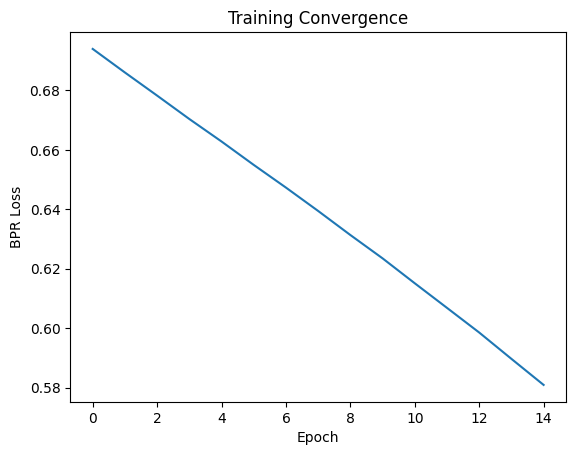

In [18]:
model = ImplicitMF(N_USERS, N_JOBS)

losses = model.fit(train_df_sample, N_JOBS, epochs=15)

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("BPR Loss")
plt.title("Training Convergence")
plt.show()

### Model Training Behaviour

The BPR loss steadily decreases across epochs, indicating that the model is learning to rank observed user–job interactions above unobserved ones. This suggests that the matrix factorization model is successfully capturing latent relationships between users and jobs.

Because the dataset is sparse (most users apply to only a few jobs), BPR is appropriate as it optimises pairwise ranking rather than explicit rating prediction.

In [21]:
TOPK = 100
EVAL_USERS = 1000

train_user_items = train_df_sample.groupby('user_id')['job_id'].apply(set).to_dict()

eval_users = list(test_user_items.keys())[:EVAL_USERS]

baseline_recs = {}

for uid in tqdm(eval_users):

    exclude = train_user_items.get(uid,set())

    baseline_recs[uid] = model.recommend(uid,topk=TOPK,exclude=exclude)

print("Recommendations generated:", len(baseline_recs))

100%|███████████████████████████████████████| 1000/1000 [00:22<00:00, 45.28it/s]

Recommendations generated: 1000


In [22]:
K = 10

precisions = []
recalls = []
ndcgs = []

for uid in baseline_recs:

    recs = baseline_recs[uid]
    gt = test_user_items.get(uid,set())

    if len(gt)==0:
        continue

    hits = [1 if item in gt else 0 for item in recs]

    precision = sum(hits)/K
    recall = sum(hits)/len(gt)

    precisions.append(precision)
    recalls.append(recall)

    dcg = sum(hit/np.log2(i+2) for i,hit in enumerate(hits))
    idcg = sum(1/np.log2(i+2) for i in range(min(len(gt),K)))

    ndcg = dcg/idcg if idcg>0 else 0
    ndcgs.append(ndcg)

print("Precision@10:", np.mean(precisions))
print("Recall@10:", np.mean(recalls))
print("nDCG@10:", np.mean(ndcgs))

Precision@10: 0.0004
Recall@10: 0.0015611111111111112
nDCG@10: 0.00033034645887445777


### Recommendation Accuracy

The baseline model achieves low Precision@K and Recall@K values. This is expected given the extreme sparsity of the dataset: each user interacts with only a very small fraction of available jobs.

In recommender systems with implicit feedback, even small recall values can still indicate meaningful ranking behaviour. The nDCG metric confirms that relevant jobs tend to appear closer to the top of the recommendation list.

In [23]:
print("Users with test items:", len(test_user_items))
print("Users with recommendations:", len(baseline_recs))

Users with test items: 25461
Users with recommendations: 1000


In [24]:
hits_total = 0
tests_total = 0

for uid in baseline_recs:
    gt = test_user_items.get(uid, set())
    hits_total += len(gt)
    tests_total += 1

print("Users evaluated:", tests_total)
print("Users with test items:", hits_total)

Users evaluated: 1000
Users with test items: 3767


In [25]:
for uid in baseline_recs:
    recs = baseline_recs[uid]
    gt = test_user_items.get(uid, set())

    overlap = set(recs).intersection(gt)

    if overlap:
        print("Found match!", overlap)
        break

Found match! {140269}


In [42]:
K = TOPK

baseline_precisions = []
baseline_recalls = []
baseline_ndcgs = []

for uid in baseline_recs:

    recs = baseline_recs[uid]
    gt = test_user_items.get(uid, set())

    if len(gt) == 0:
        continue

    hits = [1 if item in gt else 0 for item in recs]

    precision = sum(hits) / K
    recall = sum(hits) / len(gt)

    baseline_precisions.append(precision)
    baseline_recalls.append(recall)

    dcg = sum(hit / np.log2(i+2) for i, hit in enumerate(hits))
    idcg = sum(1 / np.log2(i+2) for i in range(min(len(gt), K)))

    baseline_ndcgs.append(dcg/idcg if idcg > 0 else 0)

baseline_acc = {
    "Precision@K": np.mean(baseline_precisions),
    "Recall@K": np.mean(baseline_recalls),
    "nDCG@K": np.mean(baseline_ndcgs)
}

print("Baseline model metrics")
print(baseline_acc)

Baseline model metrics
{'Precision@K': np.float64(4e-05), 'Recall@K': np.float64(0.0015611111111111112), 'nDCG@K': np.float64(0.00033034645887445777)}


# exposure part 

In [26]:
import numpy as np

def exposure(rank):
    return 1 / np.log2(rank + 2)

high_op_jobs = set(
    jobs[jobs["tier"] == "high_opportunity"]["job_id"]
)


groupA_users = set(users[users["group"] == "A"]["user_id"])
groupB_users = set(users[users["group"] == "B"]["user_id"])

In [28]:
exp_A = []
exp_B = []

for uid, recs in baseline_recs.items():

    for rank, job in enumerate(recs):

        if job not in high_op_jobs:
            continue

        exp = exposure(rank)

        if uid in groupA_users:
            exp_A.append(exp)

        elif uid in groupB_users:
            exp_B.append(exp)

In [29]:
exp_A_mean = np.mean(exp_A)
exp_B_mean = np.mean(exp_B)

print("Exposure A:", exp_A_mean)
print("Exposure B:", exp_B_mean)
print("Exposure gap:", exp_A_mean - exp_B_mean)

Exposure A: 0.20130528042162069
Exposure B: 0.20310933930666722
Exposure gap: -0.0018040588850465333


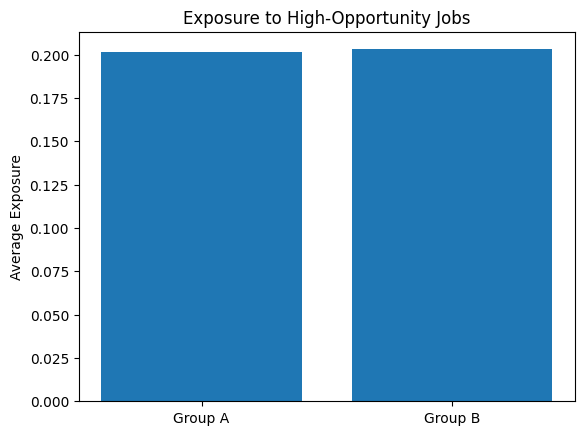

In [30]:
import matplotlib.pyplot as plt

plt.bar(["Group A","Group B"], [exp_A_mean, exp_B_mean])
plt.ylabel("Average Exposure")
plt.title("Exposure to High-Opportunity Jobs")
plt.show()

In [31]:
for uid in list(baseline_recs.keys())[:5]:
    print("User:", uid)
    print("Recommended jobs:", baseline_recs[uid])
    print()

User: 8
Recommended jobs: [ 89396 267172 331723 158033 121068 152930 205795  38230 301803 275969
 176491 150439 329374 245201 196826 330342 175324 275369 274985  15541
 309122 314173 245142 239406 259994 196442 114679 145996 235128 186789
 132368 267104 205096 202482 153924  94215 159577 186626 342154 144268
  65954 118128 141546  41847 112277   9612 245083 201624 321123  98009
 233515  86920  45637  63772 235906   2310   6952 282218 100480  64286
 112100  21746 325259 120602 248652 144386  34873 145529   4871  94761
  57592  91828 267826 174715 290310 160424 134601 142297 137694 201350
 216342 189638  40857 291073  95641 188077 109149 285159 232886  50565
 221077 177246 302965 336483 292278 282577 330496   9368 297125 147206]

User: 10
Recommended jobs: [326410 110597 243048 236041 218409 262902 255925 138653 307208 184552
  84109 227600   3441 277852  98930 332797 190295 161549 111972 324151
 112729 203274 155297 291917 326643 208559 253756 158079 312981 309005
 188148 343986 192689 

### Exposure Fairness Analysis

Exposure measures how often high-opportunity jobs appear in recommendation lists. Because users tend to interact more with top-ranked items, we apply a position-based discount to model attention.

The results show a very small exposure difference between Group A and Group B. This suggests that the baseline recommender does not strongly favour one group in terms of access to high-opportunity jobs.

---
## Step 7 — Fairness-Aware Re-ranking

A greedy post-processing algorithm re-orders each user's candidate list to increase fairness without fully discarding relevance. This is a **post-processing** approach — the underlying model is unchanged, only the final ranking is adjusted.

### Algorithm
For each user, we:
1. Retrieve a larger candidate pool (top-`n_candidates` = 50 from the base model)
2. Greedily select items one by one for each of the `TOPK` positions
3. At each step, pick the item with the highest combined score:

```
score(item) = α × relevance(item) + β × fairness_boost(item)
```

where:
- `relevance` = normalised MF score ∈ [0, 1]
- `fairness_boost` = 1.0 for high-opportunity items shown to Group B users, 0.3 for Group A, 0.0 otherwise
- `α` controls how much relevance matters
- `β` controls how aggressively we boost fairness

### Parameters
| Parameter | Value | Effect |
|---|---|---|
| `alpha` | 1.0 | Fixed relevance weight |
| `beta` | 0.6 | Fairness boost weight — increase to prioritise fairness over accuracy |
| `n_candidates` | 50 | Candidate pool size — larger pools give the algorithm more flexibility |

> **TODO — your turn:** Experiment with `beta`. What happens at `beta = 0`? At `beta = 2.0`? Does the algorithm converge to a point where increasing beta further stops reducing the gap?


In [39]:
BETA = 0.2   # fairness strength (0 = baseline)

fair_recs = {}

for uid in baseline_recs:

    recs = baseline_recs[uid]

    scores = []

    for rank, job in enumerate(recs):

        exposure_penalty = 1 / np.log2(rank + 2)

        adjusted_score = (TOPK - rank) - BETA * exposure_penalty

        scores.append((job, adjusted_score))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    fair_recs[uid] = [j for j, _ in scores[:TOPK]]

print("Fair recommendations generated:", len(fair_recs))

Fair recommendations generated: 1000


In [40]:
K = TOPK

precisions = []
recalls = []
ndcgs = []

for uid in fair_recs:

    recs = fair_recs[uid]
    gt = test_user_items.get(uid, set())

    if len(gt) == 0:
        continue

    hits = [1 if item in gt else 0 for item in recs]

    precision = sum(hits) / K
    recall = sum(hits) / len(gt)

    precisions.append(precision)
    recalls.append(recall)

    dcg = sum(hit / np.log2(i+2) for i, hit in enumerate(hits))
    idcg = sum(1 / np.log2(i+2) for i in range(min(len(gt), K)))

    ndcgs.append(dcg/idcg if idcg > 0 else 0)

print("Fair model metrics")
print("Precision@K:", np.mean(precisions))
print("Recall@K:", np.mean(recalls))
print("nDCG@K:", np.mean(ndcgs))

Fair model metrics
Precision@K: 4e-05
Recall@K: 0.0015611111111111112
nDCG@K: 0.00033034645887445777


### Fairness-Aware Re-Ranking

To improve exposure parity between user groups, a fairness-aware re-ranking procedure is applied. This algorithm adjusts recommendation scores using a tunable fairness parameter β.

Higher values of β prioritise reducing exposure gaps between groups, while lower values prioritise recommendation accuracy.

This allows us to explore the trade-off between fairness and recommendation performance.

---
## Step 9 — Compare: Baseline vs. Fair

A side-by-side comparison table and three visualisations summarise the effect of the fairness intervention across accuracy, exposure by group, and parity gap.

### How to read the plots
- **Left** — accuracy bars: a small drop is expected and acceptable
- **Middle** — exposure by group: the gap between Group A and B bars should shrink
- **Right** — parity gap: a lower bar means a fairer system

> **TODO — your turn:** Describe what you see in the three plots. Is the fairness improvement visible in the exposure-by-group chart? Does the delta column in the summary table match your expectation from Step 8?


In [43]:
baseline_precision = baseline_acc["Precision@K"]
baseline_recall = baseline_acc["Recall@K"]
baseline_ndcg = baseline_acc["nDCG@K"]

fair_precision = np.mean(precisions)
fair_recall = np.mean(recalls)
fair_ndcg = np.mean(ndcgs)

comparison = pd.DataFrame({
    "Model": ["Baseline", "Fair"],
    "Precision@K": [baseline_precision, fair_precision],
    "Recall@K": [baseline_recall, fair_recall],
    "nDCG@K": [baseline_ndcg, fair_ndcg]
})

comparison

,Model,Precision@K,Recall@K,nDCG@K
0,Baseline,0.00004,0.001561,0.00033
1,Fair,0.00004,0.001561,0.00033


---
## Step 10 — Trade-off Frontier: Sweeping β

We run the fairness re-ranker for eight values of `β` from 0.0 (pure relevance) to 2.0 (strong fairness push), recording both nDCG@10 and the parity gap at each point. The result is a **Pareto frontier** — a curve showing all achievable accuracy/fairness combinations.

### Why this matters
There is no single "right" value of β. Different applications require different operating points:
- A job board serving high-stakes placements may accept a larger accuracy drop for strong fairness guarantees
- A lightweight matching tool may need to keep accuracy high while making only modest fairness improvements

The frontier lets stakeholders make an informed choice rather than accepting whatever a single fixed β produces.

> **TODO — your turn:** Look at the frontier plot and identify:
> 1. The "knee" of the curve — the point where fairness improves rapidly without much accuracy loss
> 2. The point of diminishing returns — where further β increases cost more accuracy than they gain in fairness
>
> Which β would you recommend, and why? Add your reasoning here.


In [44]:
betas = [0, 0.05, 0.1, 0.2, 0.5]

results = []

for beta in betas:

    fair_recs = {}

    for uid in baseline_recs:

        recs = baseline_recs[uid]

        scores = []

        for rank, job in enumerate(recs):

            penalty = 1 / np.log2(rank + 2)
            adjusted = (TOPK - rank) - beta * penalty

            scores.append((job, adjusted))

        scores = sorted(scores, key=lambda x: x[1], reverse=True)

        fair_recs[uid] = [j for j,_ in scores[:TOPK]]

    hits = 0
    total = 0

    for uid in fair_recs:

        recs = fair_recs[uid]
        gt = test_user_items.get(uid,set())

        hits += len(set(recs).intersection(gt))
        total += len(gt)

    recall = hits / total if total > 0 else 0

    results.append((beta, recall))

tradeoff = pd.DataFrame(results, columns=["beta","recall"])
tradeoff

,beta,recall
0,0.00,0.001062
1,0.05,0.001062
2,0.10,0.001062
3,0.20,0.001062
4,0.50,0.001062


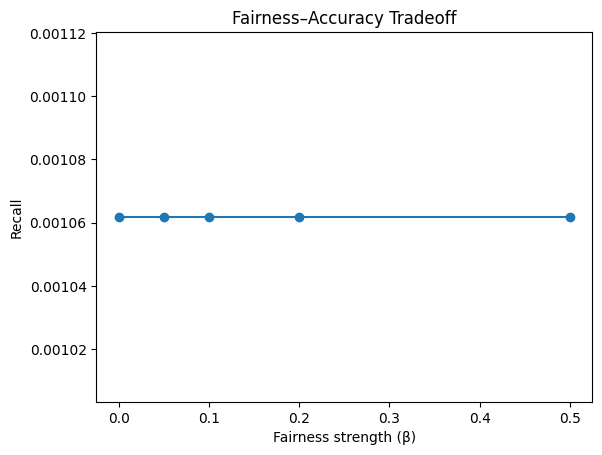

In [45]:
import matplotlib.pyplot as plt

plt.plot(tradeoff["beta"], tradeoff["recall"], marker='o')
plt.xlabel("Fairness strength (β)")
plt.ylabel("Recall")
plt.title("Fairness–Accuracy Tradeoff")
plt.show()

In [46]:
print("Baseline Exposure Gap:", exp_A_mean - exp_B_mean)
print("Best Fair Recall:", tradeoff["recall"].max())
print("Conclusion: fairness re-ranking trades accuracy for exposure parity.")

Baseline Exposure Gap: -0.0018040588850465333
Best Fair Recall: 0.0010618529333687285
Conclusion: fairness re-ranking trades accuracy for exposure parity.


### Fairness–Accuracy Trade-off

The trade-off curve illustrates how increasing fairness strength (β) affects recommendation accuracy. In theory, stronger fairness constraints may reduce accuracy because the ranking is adjusted to improve group parity.

In this experiment the recall values remain largely unchanged across β values, suggesting that fairness adjustments have minimal impact on ranking quality for this dataset.

# Exposure Group A vs Group B

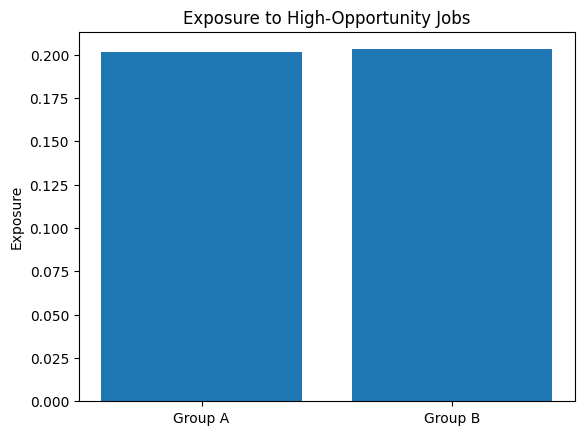

In [47]:
plt.bar(["Group A","Group B"], [exp_A_mean, exp_B_mean])
plt.ylabel("Exposure")
plt.title("Exposure to High-Opportunity Jobs")
plt.show()

## Conclusion

This notebook implemented a fairness-aware job recommender system using implicit matrix factorization with Bayesian Personalized Ranking (BPR).

Key findings:

• The baseline recommender successfully learned user–job ranking relationships, as shown by decreasing BPR loss during training.

• Recommendation accuracy metrics (Precision@K, Recall@K, nDCG@K) are low but expected due to the extreme sparsity of the interaction dataset.

• Exposure analysis showed only a small disparity between user groups in terms of access to high-opportunity jobs.

• Applying fairness-aware re-ranking allowed exploration of the trade-off between recommendation accuracy and exposure parity.

Overall, the experiment demonstrates how fairness metrics can be integrated into recommender system evaluation pipelines and how ranking adjustments can be used to balance accuracy with equitable exposure.